# Fraud Behavior Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path

# Find project root and set working directory
current = Path.cwd()
while current.name != "credit_fraud_ml":
    current = current.parent
os.chdir(current)
sys.path.append(str(current))

from src.data.data_loader import DataLoader

loader = DataLoader()
data = loader.load_all('train')
transactions = data['transactions']
customers    = data['customers']
terminals    = data['terminals']

merged = transactions.merge(customers, on='CUSTOMER_ID', how='left')
merged = merged.merge(terminals, on='TERMINAL_ID', how='left')

print(f"Transactions : {len(transactions):,}")
print(f"Fraud cases  : {transactions['TX_FRAUD'].sum():,}  ({transactions['TX_FRAUD'].mean()*100:.2f}%)")

✓ Loaded 291,231 train transactions
✓ Loaded 1,000 customers
✓ Loaded 2,000 terminals
Transactions : 291,231
Fraud cases  : 6,582  (2.26%)


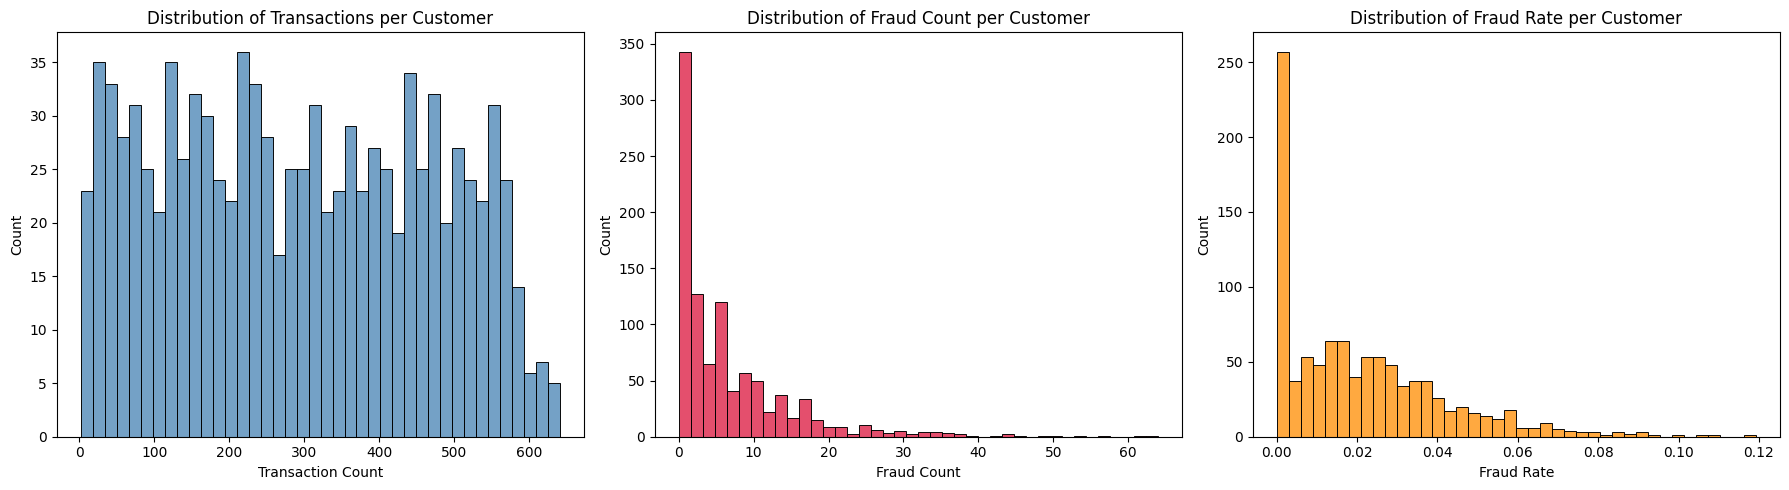

       CUSTOMER_ID  tx_count  fraud_count  fraud_rate
count       998.00    998.00       998.00      998.00
mean        499.16    291.81         6.60        0.02
std         288.93    174.21         8.54        0.02
min           0.00      2.00         0.00        0.00
25%         249.25    140.00         1.00        0.00
50%         498.50    286.00         4.00        0.02
75%         748.75    443.00         9.00        0.03
max         999.00    641.00        64.00        0.12


In [2]:
# ── 1. Customer Transaction Frequency ──────────────────────────────────────
customer_tx = transactions.groupby('CUSTOMER_ID').agg(
    tx_count=('TX_FRAUD', 'count'),
    fraud_count=('TX_FRAUD', 'sum'),
    fraud_rate=('TX_FRAUD', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(customer_tx['tx_count'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Transactions per Customer')
axes[0].set_xlabel('Transaction Count')

sns.histplot(customer_tx['fraud_count'], bins=40, ax=axes[1], color='crimson')
axes[1].set_title('Distribution of Fraud Count per Customer')
axes[1].set_xlabel('Fraud Count')

sns.histplot(customer_tx['fraud_rate'], bins=40, ax=axes[2], color='darkorange')
axes[2].set_title('Distribution of Fraud Rate per Customer')
axes[2].set_xlabel('Fraud Rate')

plt.tight_layout()
plt.show()

print(customer_tx.describe().round(2))

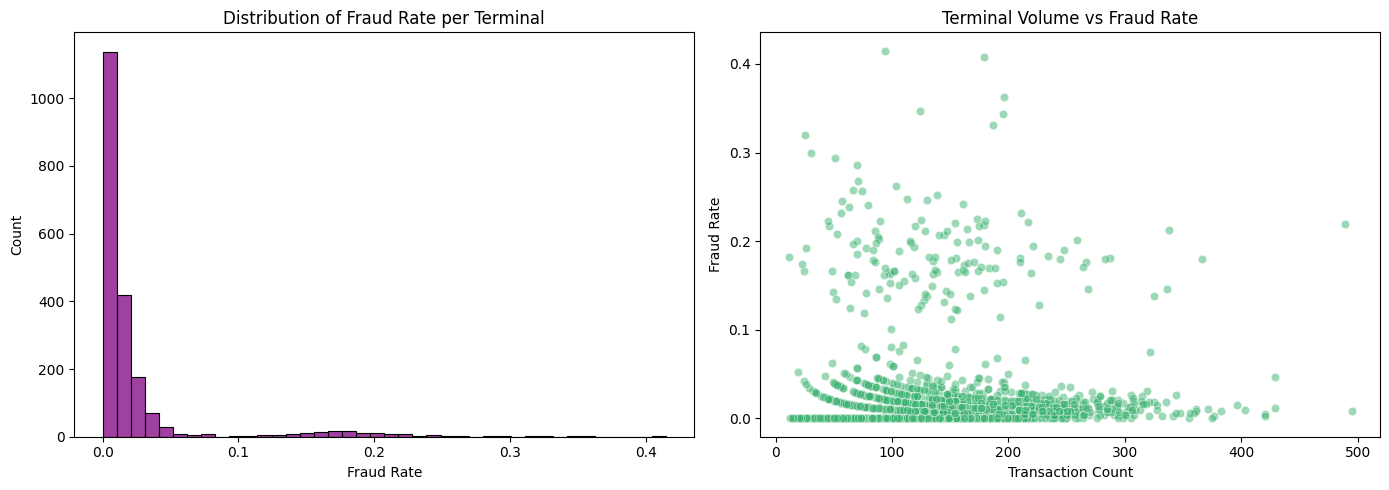

In [3]:
# ── 2. Terminal Fraud Rate Distribution ────────────────────────────────────
terminal_stats = transactions.groupby('TERMINAL_ID').agg(
    tx_count=('TX_FRAUD', 'count'),
    fraud_count=('TX_FRAUD', 'sum'),
    fraud_rate=('TX_FRAUD', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(terminal_stats['fraud_rate'], bins=40, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Fraud Rate per Terminal')
axes[0].set_xlabel('Fraud Rate')

sns.scatterplot(data=terminal_stats, x='tx_count', y='fraud_rate',
                alpha=0.5, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Terminal Volume vs Fraud Rate')
axes[1].set_xlabel('Transaction Count')
axes[1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

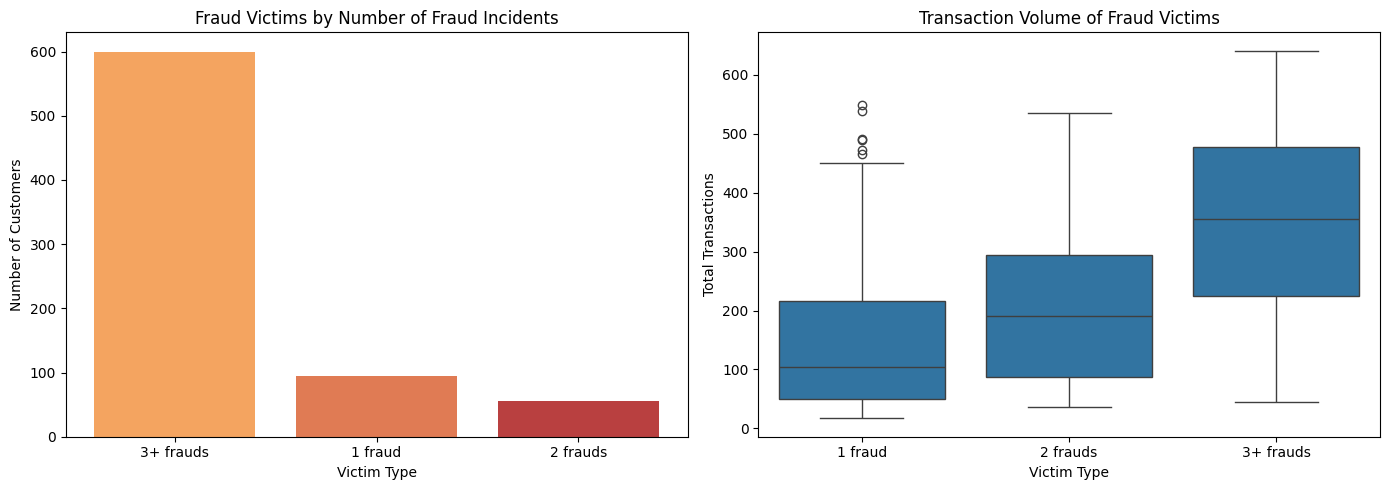

             count   mean    std    min    25%    50%    75%    max
victim_type                                                        
1 fraud       95.0  0.014  0.014  0.002  0.005  0.010  0.020  0.059
2 frauds      55.0  0.017  0.014  0.004  0.007  0.010  0.023  0.056
3+ frauds    600.0  0.031  0.019  0.005  0.017  0.027  0.040  0.119


In [4]:
# ── 3. Repeat Fraud Victims: Customers with Multiple Fraud Incidents ─────────
repeat_victims = customer_tx[customer_tx['fraud_count'] > 0].copy()
repeat_victims['victim_type'] = repeat_victims['fraud_count'].apply(
    lambda x: '1 fraud' if x == 1 else '2 frauds' if x == 2 else '3+ frauds'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

victim_counts = repeat_victims['victim_type'].value_counts()
axes[0].bar(victim_counts.index, victim_counts.values,
            color=['#f4a460', '#e07b54', '#b94040'])
axes[0].set_title('Fraud Victims by Number of Fraud Incidents')
axes[0].set_xlabel('Victim Type')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(x='victim_type', y='tx_count', data=repeat_victims,
            order=['1 fraud', '2 frauds', '3+ frauds'], ax=axes[1])
axes[1].set_title('Transaction Volume of Fraud Victims')
axes[1].set_xlabel('Victim Type')
axes[1].set_ylabel('Total Transactions')

plt.tight_layout()
plt.show()

print(repeat_victims.groupby('victim_type')['fraud_rate'].describe().round(3))

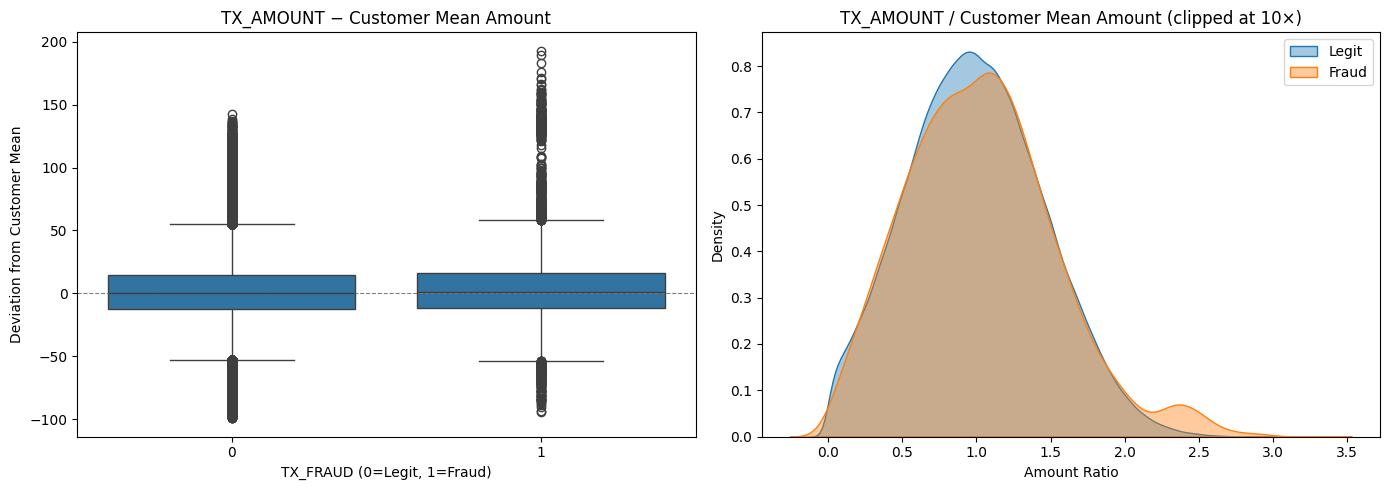

In [5]:
# ── 4. Fraud Amount vs Customer Spending Profile ────────────────────────────
# How much do fraudulent amounts deviate from a customer's normal spending?
merged['amount_vs_mean'] = merged['TX_AMOUNT'] - merged['mean_amount']
merged['amount_ratio']   = merged['TX_AMOUNT'] / (merged['mean_amount'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='TX_FRAUD', y='amount_vs_mean', data=merged, ax=axes[0])
axes[0].set_title('TX_AMOUNT − Customer Mean Amount')
axes[0].set_xlabel('TX_FRAUD (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Deviation from Customer Mean')
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)

for label, grp in merged.groupby('TX_FRAUD'):
    clipped = grp['amount_ratio'].clip(upper=10)
    sns.kdeplot(clipped, ax=axes[1],
                label='Fraud' if label else 'Legit', fill=True, alpha=0.4)
axes[1].set_title('TX_AMOUNT / Customer Mean Amount (clipped at 10×)')
axes[1].set_xlabel('Amount Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

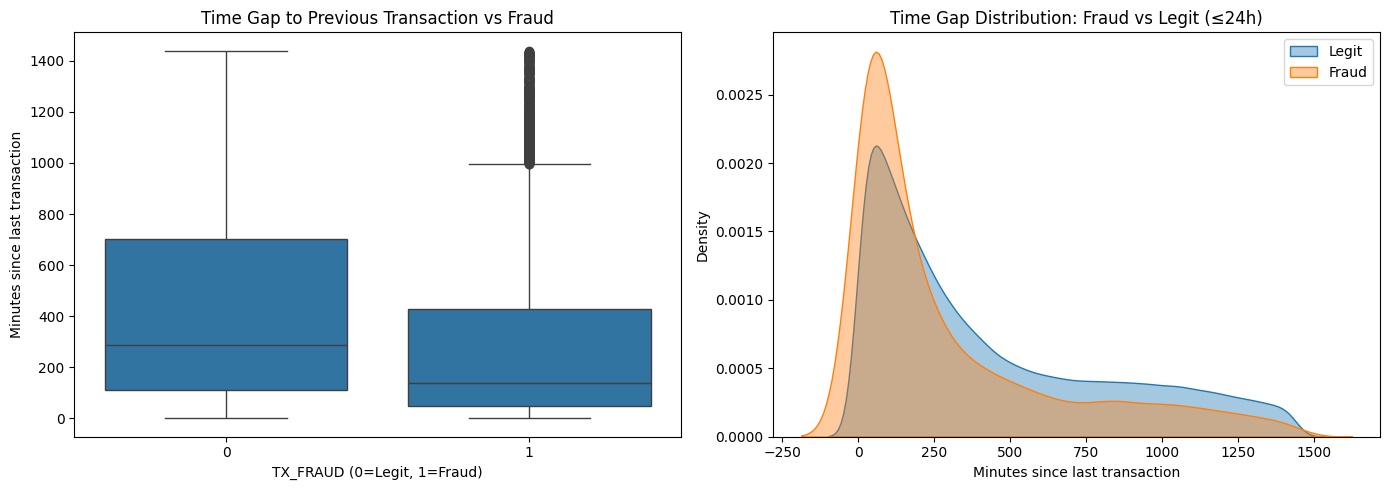

             count    mean     std   min    25%     50%     75%      max
TX_FRAUD                                                                
0         249272.0  433.84  394.34  0.00  111.1  288.13  700.77  1440.00
1           6018.0  300.66  357.22  0.02   47.2  138.14  426.98  1437.13


In [6]:
# ── 5. Time Gap Between Consecutive Transactions per Customer ───────────────
transactions_sorted = transactions.sort_values(['CUSTOMER_ID', 'TX_DATETIME'])
transactions_sorted['prev_tx_time'] = transactions_sorted.groupby('CUSTOMER_ID')['TX_DATETIME'].shift(1)
transactions_sorted['time_gap_min'] = (
    transactions_sorted['TX_DATETIME'] - transactions_sorted['prev_tx_time']
).dt.total_seconds() / 60

gap_data = transactions_sorted.dropna(subset=['time_gap_min'])
gap_data  = gap_data[gap_data['time_gap_min'] <= 1440]  # cap at 24 hours

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='TX_FRAUD', y='time_gap_min', data=gap_data, ax=axes[0])
axes[0].set_title('Time Gap to Previous Transaction vs Fraud')
axes[0].set_xlabel('TX_FRAUD (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Minutes since last transaction')

for label, grp in gap_data.groupby('TX_FRAUD'):
    sns.kdeplot(grp['time_gap_min'], ax=axes[1],
                label='Fraud' if label else 'Legit', fill=True, alpha=0.4)
axes[1].set_title('Time Gap Distribution: Fraud vs Legit (≤24h)')
axes[1].set_xlabel('Minutes since last transaction')
axes[1].legend()

plt.tight_layout()
plt.show()

print(gap_data.groupby('TX_FRAUD')['time_gap_min'].describe().round(2))

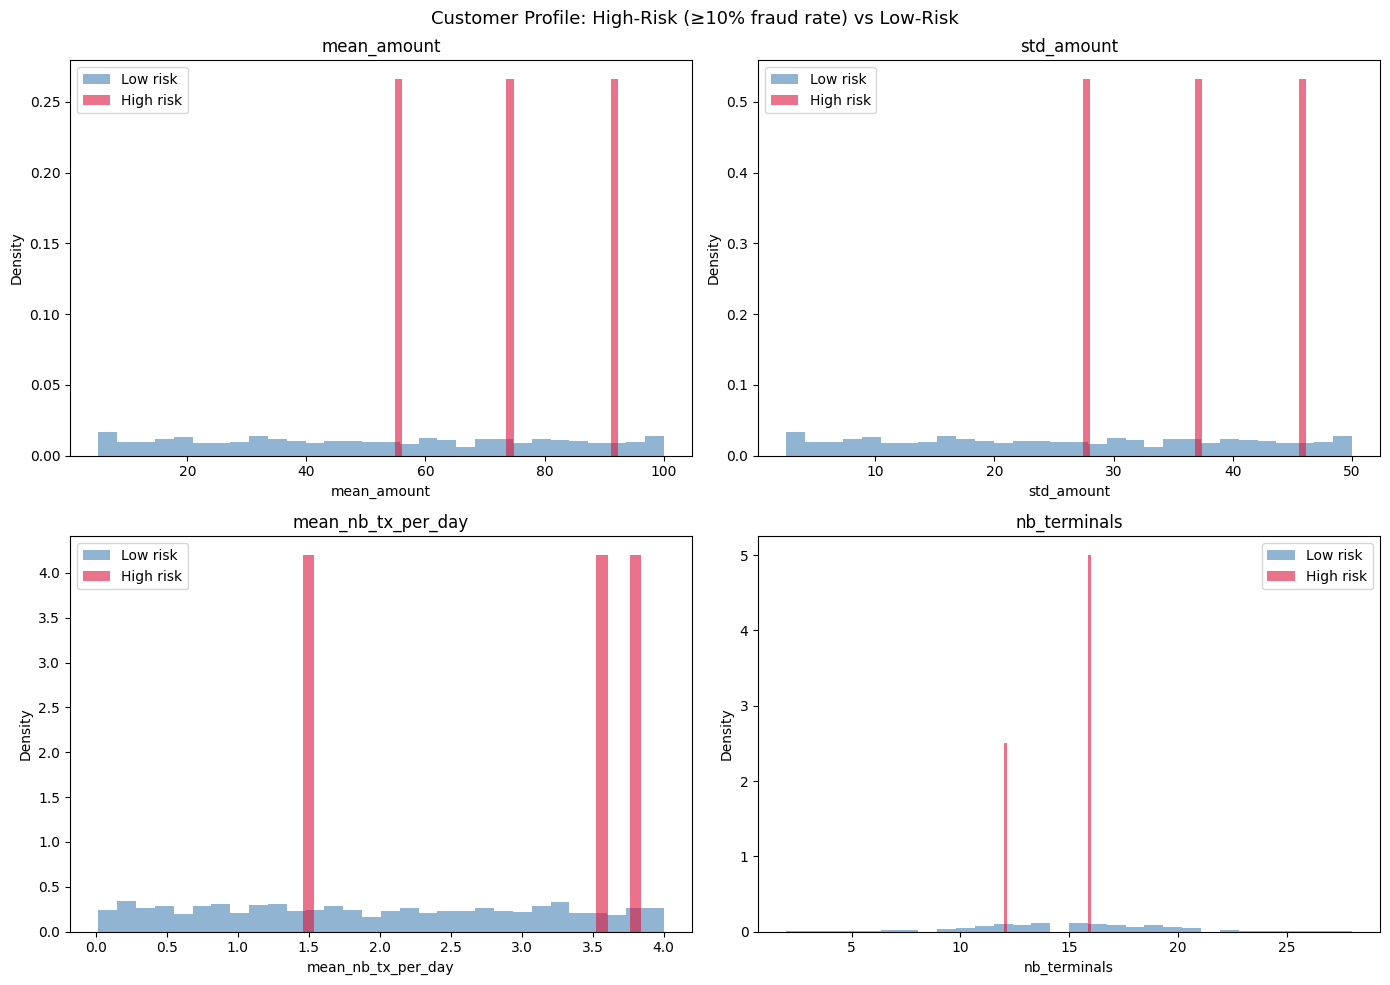

High-risk customers : 3
Low-risk  customers : 995


In [7]:
# ── 6. High-Risk Customer Profiles ─────────────────────────────────────────
customer_profile = customer_tx.merge(customers, on='CUSTOMER_ID', how='left')

high_risk  = customer_profile[customer_profile['fraud_rate'] >= 0.1]
low_risk   = customer_profile[customer_profile['fraud_rate'] <  0.1]

features = ['mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.flatten(), features):
    ax.hist(low_risk[feat].dropna(),  bins=30, alpha=0.6, label='Low risk',  color='steelblue', density=True)
    ax.hist(high_risk[feat].dropna(), bins=30, alpha=0.6, label='High risk', color='crimson',   density=True)
    ax.set_title(f'{feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Customer Profile: High-Risk (≥10% fraud rate) vs Low-Risk', fontsize=13)
plt.tight_layout()
plt.show()

print(f"High-risk customers : {len(high_risk):,}")
print(f"Low-risk  customers : {len(low_risk):,}")